# GCN-BiGRU Intrusion Detection Pipeline

Unified notebook for **NSL-KDD**, **CICIDS2017**, and **UNSW-NB15**.

Set `DATASET` in the config cell below to `"nslkdd"`, `"cicids"`, or `"unsw"` and run all cells.
Every dataset uses the same preprocessing recipe (median imputation, log1p feature augmentation,
standardization, low-variance filtering) and the same GCN-BiGRU architecture.

Pipeline overview:
1. Configuration
2. Load raw data (dataset-specific: files/columns/labels differ per benchmark)
3. Shared preprocessing: split -> impute -> log1p -> scale -> variance filter
4. Feature-correlation graph for the GCN front-end
5. Adaptive graph-convolution layer (learnable adjacency, Phase 3A)
6. GCN-BiGRU model definition
7. Class weights
8. **Secretary Bird Optimization Algorithm (SBOA)** hyperparameter search (Phase 1)
9. Final model training at full epochs/full data with the SBOA-selected hyperparameters
10. Evaluation: performance table, confusion matrix, class-wise indicators, ROC curve, timing

Reproducibility scaffolding (Phase 0): GPU is used when available (with memory growth and
optional `mixed_float16`), all results are persisted to `results/results_<dataset>.json` so
tables/plots can be rebuilt without re-running training, and package versions are printed for
the reproducibility statement.


In [1]:
# ============================================================
# CONFIGURATION -- choose the dataset to run the pipeline on
# ============================================================
DATASET = "ton_iot"  # one of: "nslkdd", "cicids", "unsw", "ciciot23", "edge_iiot", "ton_iot"

SEED       = 42
EPOCHS     = 100
BATCH      = 512
TIMESTEPS  = 1
DROPOUT    = 0.3
REG        = 1e-3
TOP_K      = 8        # GCN adjacency: neighbors kept per feature (default / fallback)
LR         = 1e-3
TEST_FRAC  = 0.15
VAL_FRAC   = 0.176     # of the remaining 85% -> overall ~70 / 15 / 15 split

# --- Phase 0: reproducibility / scaffolding -----------------------------
SEEDS            = [42, 1, 7, 13, 21]  # reserved for multi-seed robustness runs (Phase 2)
NSL_NATIVE_SPLIT = False               # NSL-KDD only: use native KDDTrain+/KDDTest+ split
                                        # (distribution-shift eval) instead of a random 70/15/15 split

# --- Phase 1: Secretary Bird Optimization Algorithm (SBOA) hyperparameter search ---
RUN_SBOA          = True   # if False, reuse a cached theta* (results/results_<dataset>.json) or defaults
SBOA_SAMPLE_FRAC  = 0.15   # fraction of the training split used during the SBOA search
SBOA_POP          = 8      # population size P
SBOA_ITERS        = 12     # iterations T
SBOA_EPOCHS       = 12     # reduced training budget per candidate evaluation
FINAL_FULL_DATA   = True   # retrain the final model on the full training split (vs. the SBOA subsample)

# --- Phase 3A: adaptive / learned graph -----------------------------------
ADAPTIVE_GRAPH = True   # True: learnable adjacency initialized from Pearson correlation
                         # False: fixed Pearson-correlation adjacency (original SimpleGCN behaviour)

# --- Multi-dataset selection --------------------------------------------
DATASETS_ALL = ("nslkdd", "cicids", "unsw", "ciciot23", "edge_iiot", "ton_iot")

# Batch runner (final section): list the datasets to evaluate in one go. Each runs as a
# fully independent pass and writes results/results_<dataset>.json; SBOA is skipped for any
# dataset that already has cached hyperparameters (see run_pipeline).
DATASETS_TO_RUN = ["ton_iot", "ciciot23", "edge_iiot"]

# Optional stratified row cap per dataset (None -> use all rows). The three new IoT benchmarks
# are very large; capping keeps training tractable. Raise/remove for paper-grade full runs.
MAX_SAMPLES = {
    "ciciot23":  500_000,   # ~7.8M rows pooled
    "edge_iiot": 500_000,   # ~2.2M rows
    "ton_iot":   None,      # ~0.42M rows -> use all
}

assert DATASET in DATASETS_ALL, f"Unknown DATASET: {DATASET}"


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["PYTHONHASHSEED"] = str(SEED)

import json as _json
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.ndimage import uniform_filter1d
from scipy.special import gamma as sp_gamma

import tensorflow as tf

# GPU: enable memory growth so TF doesn't reserve all VRAM up front; silently falls back
# to CPU if no GPU is visible (e.g. on a CI machine or a laptop without CUDA).
GPUS = tf.config.list_physical_devices("GPU")
for _gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass

import keras

USE_MIXED_PRECISION = len(GPUS) > 0
if USE_MIXED_PRECISION:
    keras.mixed_precision.set_global_policy("mixed_float16")

from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization, Bidirectional, GRU
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
    classification_report, confusion_matrix, matthews_corrcoef,
    roc_curve, auc,
)

np.random.seed(SEED)
tf.random.set_seed(SEED)

MODEL_NAME = "BG-GCN"
print(f"Dataset selected : {DATASET}")
print(f"GPUs visible to TensorFlow: {len(GPUS)} | "
      f"Mixed precision: {'mixed_float16' if USE_MIXED_PRECISION else 'float32 (no GPU)'}")
print(f"Python {platform.python_version()} | TensorFlow {tf.__version__} | Keras {keras.__version__} | "
      f"NumPy {np.__version__} | Pandas {pd.__version__} | scikit-learn {sklearn.__version__}")


c:\Users\ashis\miniconda3\envs\tf\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
Dataset selected : unsw
GPUs visible to TensorFlow: 1 | Mixed precision: mixed_float16
Python 3.9.25 | TensorFlow 2.10.1 | Keras 2.10.0 | NumPy 1.26.4 | Pandas 2.2.3 | scikit-learn 1.5.2


## Results Persistence
All headline numbers (SBOA search results, performance tables, timing) are accumulated in the
`RESULTS` dict and written to `results/results_<dataset>.json`. Re-running with `RUN_SBOA = False`
reloads the cached search results instead of repeating the (expensive) hyperparameter search.

In [3]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _results_path(dataset=None):
    return RESULTS_DIR / f"results_{dataset or DATASET}.json"

def save_results(dataset=None):
    path = _results_path(dataset)
    with open(path, "w") as f:
        _json.dump(RESULTS, f, indent=2, default=float)
    print(f"Saved results -> {path}")

def load_results(dataset=None):
    path = _results_path(dataset)
    if path.exists():
        with open(path) as f:
            return _json.load(f)
    return {}

RESULTS = load_results(DATASET)


## 1. Load Raw Data
Each dataset has its own file layout and label scheme; loaders below return a common
`(X, y, CLASS_ORDER, NATIVE_TEST_MASK)` tuple. `NATIVE_TEST_MASK` is a boolean array marking
rows that belong to the dataset's own official test file (only meaningful for NSL-KDD's
KDDTrain+/KDDTest+ split); it is `None` for datasets that ship a single pooled file.

In [4]:
def find_dataset_root():
    '''Locate the `dataset/` folder: check cwd, then up to two parent directories.

    Notebooks are typically run with cwd set to the notebook's own directory, but the
    shared `dataset/` folder may live a couple of levels up (e.g. next to a `Publications/`
    or project root). Checking a few parent levels lets every loader work whether the
    notebook is opened from its own folder or from somewhere above it.
    '''
    for c in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (c / "dataset").exists():
            return c / "dataset"
    return Path.cwd() / "dataset"


def load_nslkdd():
    '''NSL-KDD: KDDTrain+.txt / KDDTest+.txt, manual attack-subclass -> 5-category mapping.'''
    DATA_DIR = find_dataset_root() / "nslkdd"
    for fname in ["KDDTrain+.txt", "KDDTest+.txt"]:
        if not (DATA_DIR / fname).exists():
            raise FileNotFoundError(f"Missing required dataset file: {DATA_DIR / fname}")

    col_names = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
        "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
        "root_shell","su_attempted","num_root","num_file_creations","num_shells",
        "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
        "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
        "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
        "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
        "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
        "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
        "subclass","difficulty_level"]

    df_train = pd.read_csv(DATA_DIR / "KDDTrain+.txt", header=None, names=col_names).drop("difficulty_level", axis=1)
    df_test  = pd.read_csv(DATA_DIR / "KDDTest+.txt",  header=None, names=col_names).drop("difficulty_level", axis=1)
    native_test_mask = np.concatenate([np.zeros(len(df_train), dtype=bool), np.ones(len(df_test), dtype=bool)])
    combined = pd.concat([df_train, df_test], ignore_index=True)

    # One-hot encode categorical columns
    for c in ["protocol_type", "service", "flag"]:
        dummies = pd.get_dummies(combined[c], prefix=c, drop_first=False, dtype=np.uint8)
        combined = pd.concat([combined.drop(c, axis=1), dummies], axis=1)

    subclass = combined.pop("subclass")

    # Map raw attack subclasses -> 5 top-level categories
    dos_set   = {"apache2","back","land","neptune","mailbomb","pod","processtable","smurf","teardrop","udpstorm","worm"}
    probe_set = {"ipsweep","mscan","nmap","portsweep","saint","satan"}
    u2r_set   = {"buffer_overflow","loadmodule","perl","ps","rootkit","sqlattack","xterm"}
    r2l_set   = {"ftp_write","guess_passwd","httptunnel","imap","multihop","named","phf","sendmail",
                 "Snmpgetattack","spy","snmpguess","warezclient","warezmaster","xlock","xsnoop"}

    def map_class(v):
        if v in dos_set:   return "DoS"
        if v in probe_set: return "Probe"
        if v in u2r_set:   return "U2R"
        if v in r2l_set:   return "R2L"
        return "Normal"

    class_order = ["DoS", "Normal", "Probe", "R2L", "U2R"]
    class_to_idx = {c: i for i, c in enumerate(class_order)}
    y = subclass.map(map_class).map(class_to_idx).astype(np.int32).values
    X = combined.values.astype(np.float32)
    return X, y, class_order, native_test_mask


def load_cicids():
    '''CICIDS2017: 8 raw per-day ISCX CSVs, concatenated and mapped to a reduced Attack Type scheme.

    The official release ships one CSV per capture day (Monday .. Friday, with Friday split
    into DDoS/PortScan/Bot captures) rather than a single pre-cleaned file. A parquet cache of
    the concatenated + labeled result is written next to the raw files so repeat runs skip the
    (slow) CSV concatenation.
    '''
    DATA_DIR = find_dataset_root() / "cicids"
    parquet_path = DATA_DIR / "cicids2017_combined.parquet"

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path).drop_duplicates()
    else:
        raw_files = sorted(DATA_DIR.glob("*.pcap_ISCX.csv"))
        if not raw_files:
            raise FileNotFoundError(f"No raw CICIDS2017 *_ISCX.csv files found under {DATA_DIR}")
        frames = []
        for f in raw_files:
            d = pd.read_csv(f, low_memory=False)
            d.columns = [c.strip() for c in d.columns]
            frames.append(d)
        df = pd.concat(frames, ignore_index=True).drop_duplicates()
        df.to_parquet(parquet_path, index=False)

    # Raw `Label` values -> a reduced Attack Type scheme (8 top-level categories).
    # Heartbleed (11 samples in the official release) is folded into DoS since it is too
    # rare to support a stratified split on its own; FTP/SSH-Patator and the three Web
    # Attack subtypes are grouped the same way for the same reason.
    def map_attack(v):
        vl = v.strip().lower()
        if vl == "benign":
            return "Normal"
        if vl.startswith("web attack"):
            return "Web Attack"
        if vl in ("ftp-patator", "ssh-patator"):
            return "Brute Force"
        if vl.startswith("dos") or vl == "heartbleed":
            return "DoS"
        if vl == "ddos":
            return "DDoS"
        if vl == "portscan":
            return "PortScan"
        if vl == "bot":
            return "Bot(s)"
        if vl == "infiltration":
            return "Infiltration"
        return "Other"

    attack_type = df["Label"].astype(str).map(map_attack)

    le = LabelEncoder()
    y = le.fit_transform(attack_type)
    class_order = list(le.classes_)

    # Put the "Bot(s)" class last, matching the paper's confusion-matrix ordering
    bot_label = next((l for l in class_order if "bot" in l.lower()), None)
    if bot_label and class_order.index(bot_label) != len(class_order) - 1:
        old_order = list(le.classes_)
        class_order.remove(bot_label)
        class_order.append(bot_label)
        remap = {old_i: class_order.index(name) for old_i, name in enumerate(old_order)}
        y = np.array([remap[v] for v in y])

    drop_cols = [c for c in ["Label", "Flow ID", "Source IP", "Destination IP",
                              "Timestamp", "Src IP", "Dst IP"] if c in df.columns]
    X = df.drop(columns=drop_cols).select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
    return X.values.astype(np.float32), y.astype(np.int32), class_order, None


def load_unsw():
    '''UNSW-NB15: training/testing CSVs (or parquet cache), numeric + one-hot categoricals.'''
    DATA_DIR, LABEL_COL = find_dataset_root() / "unsw", "attack_cat"
    parquet_path = DATA_DIR / "unsw_nb15_combined.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path).drop_duplicates()
    else:
        train_path = DATA_DIR / "UNSW_NB15_training-set.csv"
        test_path  = DATA_DIR / "UNSW_NB15_testing-set.csv"
        if not train_path.exists():
            raise FileNotFoundError(f"Missing required dataset file: {train_path}")
        df_train = pd.read_csv(train_path)
        df_test  = pd.read_csv(test_path)
        df = pd.concat([df_train, df_test], ignore_index=True).drop_duplicates()
        df.to_parquet(parquet_path, index=False)

    for col in ["id", "label"]:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)
    df.dropna(subset=[LABEL_COL], inplace=True)

    le = LabelEncoder()
    y = le.fit_transform(df[LABEL_COL].astype(str).str.strip())
    class_order = list(le.classes_)

    cat_cols = [c for c in ["proto", "service", "state"] if c in df.columns]
    X_num = df.drop(columns=[LABEL_COL] + cat_cols).select_dtypes(include=[np.number]).copy()
    X_cat = (pd.get_dummies(df[cat_cols].astype(str), prefix=cat_cols, dummy_na=False)
             if cat_cols else pd.DataFrame(index=df.index))
    X = pd.concat([X_num, X_cat], axis=1).astype(np.float32).replace([np.inf, -np.inf], np.nan)
    return X.values.astype(np.float32), y.astype(np.int32), class_order, None




# ---- Additional IoT benchmark loaders: CICIOT23, Edge-IIoT, TON_IoT ------------------
def _prep_tabular(df, label_col, drop_cols, onehot_cap=50):
    '''Shared tabular prep: drop id/leakage columns, one-hot low-cardinality categoricals,
    keep numeric features. Returns (X float32 with possible NaN, y int32, class_order).'''
    y_raw = df[label_col].astype(str).str.strip()
    drop = {label_col} | {c for c in drop_cols if c in df.columns}
    feat = df.drop(columns=list(drop))
    obj_cols = feat.select_dtypes(include="object").columns.tolist()
    keep_oh = [c for c in obj_cols if feat[c].nunique() <= onehot_cap]
    drop_hi = [c for c in obj_cols if c not in keep_oh]           # high-cardinality strings -> drop
    feat = feat.drop(columns=drop_hi)
    X_num = feat.drop(columns=keep_oh).apply(pd.to_numeric, errors="coerce")
    X_cat = (pd.get_dummies(feat[keep_oh].astype(str), prefix=keep_oh, dummy_na=False)
             if keep_oh else pd.DataFrame(index=feat.index))
    X = pd.concat([X_num, X_cat], axis=1).replace([np.inf, -np.inf], np.nan)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    return X.values.astype(np.float32), y.astype(np.int32), list(le.classes_)


def load_ciciot23():
    '''CIC-IoT-2023: pooled train/validation/test CSVs; 34 fine labels -> 8 top-level groups.'''
    D = find_dataset_root() / "CICIOT23"
    parts = [D / "train" / "train.csv", D / "validation" / "validation.csv", D / "test" / "test.csv"]
    frames = [pd.read_csv(p) for p in parts if p.exists()]
    if not frames:
        raise FileNotFoundError(f"No CICIOT23 CSVs found under {D}")
    df = pd.concat(frames, ignore_index=True)

    def grp(v):
        v = str(v)
        if v == "BenignTraffic": return "Benign"
        if v.startswith("DDoS"):  return "DDoS"
        if v.startswith("DoS"):   return "DoS"
        if v.startswith("Mirai"): return "Mirai"
        if v.startswith("Recon") or v == "VulnerabilityScan": return "Recon"
        if v in ("MITM-ArpSpoofing", "DNS_Spoofing"): return "Spoofing"
        if v == "DictionaryBruteForce": return "BruteForce"
        return "Web"   # BrowserHijacking, CommandInjection, SqlInjection, XSS, Backdoor_Malware, Uploading_Attack

    class_order = ["Benign", "DDoS", "DoS", "Mirai", "Recon", "Spoofing", "Web", "BruteForce"]
    c2i = {c: i for i, c in enumerate(class_order)}
    y = df["label"].map(grp).map(c2i).astype(np.int32).values
    X = (df.drop(columns=["label"]).select_dtypes(include=[np.number])
           .replace([np.inf, -np.inf], np.nan).values.astype(np.float32))
    return X, y, class_order, None


def load_edge_iiot():
    '''Edge-IIoTset (DNN CSV): 15-class Attack_type; drop identifier/hex/timestamp columns.'''
    D = find_dataset_root() / "Edge_iiot"
    df = pd.read_csv(D / "DNN-EdgeIIoT-dataset.csv", low_memory=False)
    drop_id = ["frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4",
               "arp.dst.proto_ipv4", "http.request.full_uri", "http.request.uri.query",
               "http.file_data", "http.referer", "tcp.options", "tcp.payload",
               "mqtt.msg", "dns.qry.name", "Attack_label"]
    X, y, class_order = _prep_tabular(df, "Attack_type", drop_id, onehot_cap=50)
    return X, y, class_order, None


def load_ton_iot():
    '''TON_IoT (train_test_network): 10-class `type`; drop IP / high-cardinality string identifiers.'''
    D = find_dataset_root() / "ton_iot"
    df = pd.read_csv(D / "train_test_network_full.csv")
    drop_id = ["src_ip", "dst_ip", "dns_query", "ssl_subject", "ssl_issuer",
               "http_uri", "http_user_agent", "label"]
    X, y, class_order = _prep_tabular(df, "type", drop_id, onehot_cap=50)
    return X, y, class_order, None


LOADERS = {"nslkdd": load_nslkdd, "cicids": load_cicids, "unsw": load_unsw,
           "ciciot23": load_ciciot23, "edge_iiot": load_edge_iiot, "ton_iot": load_ton_iot}
X_raw, y_all, CLASS_ORDER, NATIVE_TEST_MASK = LOADERS[DATASET]()

# Optional stratified row cap for very large datasets (see MAX_SAMPLES in the config cell).
_cap = MAX_SAMPLES.get(DATASET) if isinstance(MAX_SAMPLES, dict) else MAX_SAMPLES
if _cap and len(X_raw) > _cap:
    X_raw, _, y_all, _ = train_test_split(X_raw, y_all, train_size=_cap,
                                          random_state=SEED, stratify=y_all)
    NATIVE_TEST_MASK = None
    print(f"[{DATASET}] stratified cap -> {_cap:,} rows (MAX_SAMPLES)")

NUM_CLASSES = len(CLASS_ORDER)

print(f"[{DATASET}] Raw features: {X_raw.shape[1]} | Samples: {X_raw.shape[0]:,} | Classes: {NUM_CLASSES}")
for i, c in enumerate(CLASS_ORDER):
    print(f"  {c}: {(y_all==i).mean()*100:.2f}%")


[unsw] Raw features: 196 | Samples: 257,673 | Classes: 10
  Analysis: 1.04%
  Backdoor: 0.90%
  DoS: 6.35%
  Exploits: 17.28%
  Fuzzers: 9.41%
  Generic: 22.85%
  Normal: 36.09%
  Reconnaissance: 5.43%
  Shellcode: 0.59%
  Worms: 0.07%


## 2. Split and Shared Preprocessing
By default: 70/15/15 stratified split. If `NSL_NATIVE_SPLIT = True` and `DATASET == "nslkdd"`,
the test split instead uses the dataset's own KDDTest+ rows (which contain attack subtypes not
seen in KDDTrain+), giving a genuine distribution-shift evaluation rather than an i.i.d. random
split. Either way, imputation / augmentation / scaling / variance-filtering are fit on the
training split only, to avoid leakage.

In [5]:
if DATASET == "nslkdd" and NSL_NATIVE_SPLIT and NATIVE_TEST_MASK is not None:
    test_idx  = np.where(NATIVE_TEST_MASK)[0]
    train_idx = np.where(~NATIVE_TEST_MASK)[0]
    X_test, y_test = X_raw[test_idx], y_all[test_idx]
    X_tmp, y_tmp   = X_raw[train_idx], y_all[train_idx]
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=VAL_FRAC, random_state=SEED, stratify=y_tmp
    )
    print("Using NSL-KDD's native KDDTrain+/KDDTest+ split (distribution-shift evaluation).")
else:
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X_raw, y_all, test_size=TEST_FRAC, random_state=SEED, stratify=y_all
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=VAL_FRAC, random_state=SEED, stratify=y_tmp
    )

# Median imputation (fit on train only)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# Feature engineering: append log1p (network traffic features are heavy-tailed)
def add_log(X):
    return np.hstack([X, np.log1p(np.clip(X, 0, None))])
X_train = add_log(X_train)
X_val   = add_log(X_val)
X_test  = add_log(X_test)

# Standardize using training statistics only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Remove near-zero-variance features (fit on train only)
vt = VarianceThreshold(threshold=1e-4)
X_train = vt.fit_transform(X_train)
X_val   = vt.transform(X_val)
X_test  = vt.transform(X_test)
NUM_FEATURES = X_train.shape[1]

# Reshape -> (samples, timesteps=1, features) for BiGRU
X_train_lstm = X_train.reshape(-1, TIMESTEPS, NUM_FEATURES)
X_val_lstm   = X_val.reshape(-1, TIMESTEPS, NUM_FEATURES)
X_test_lstm  = X_test.reshape(-1, TIMESTEPS, NUM_FEATURES)

print(f"Features after log1p augmentation + variance filter: {NUM_FEATURES}")
print(f"Train: {X_train_lstm.shape} | Val: {X_val_lstm.shape} | Test: {X_test_lstm.shape}")


Features after log1p augmentation + variance filter: 390
Train: (180474, 1, 390) | Val: (38548, 1, 390) | Test: (38651, 1, 390)


## 3. Feature-Correlation Graph for the GCN Front-End
A feature-feature adjacency matrix is built from absolute Pearson correlations on the training
split. `compute_corr_matrix` is computed **once**; `adjacency_from_corr` then applies a top-k
neighborhood filter and symmetric degree normalization. Separating the two lets the (expensive)
correlation matrix be reused cheaply whenever `top_k` changes -- both during the SBOA search and
when initializing the adaptive graph layer below.

In [6]:
def compute_corr_matrix(X):
    corr = np.abs(np.corrcoef(X, rowvar=False))
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 1.0)
    return corr

def adjacency_from_corr(corr, top_k):
    mask = np.zeros_like(corr)
    mask[np.arange(corr.shape[0])[:, None], np.argsort(corr, axis=1)[:, -top_k:]] = 1.0
    A = np.maximum(corr * mask, (corr * mask).T)
    np.fill_diagonal(A, 1.0)
    deg_inv_sqrt = np.power(A.sum(axis=1) + 1e-8, -0.5)
    return (deg_inv_sqrt[:, None] * A) * deg_inv_sqrt[None, :]

def build_feature_adjacency(X, top_k=8):
    return adjacency_from_corr(compute_corr_matrix(X), top_k)

CORR_TRAIN = compute_corr_matrix(X_train)
A_norm = adjacency_from_corr(CORR_TRAIN, TOP_K)
print(f"Adjacency: {A_norm.shape}")


Adjacency: (390, 390)


## 4. Adaptive Graph Convolution Layer (Phase 3A)
`AdaptiveGCN` generalizes the original fixed-adjacency graph convolution:

- **`adaptive=True`** (default): the adjacency is a **trainable weight**, warm-started from the
  Pearson-correlation graph above (`init_adjacency`) so training starts from an interpretable,
  data-driven prior. On every forward pass the raw weight is projected back onto a valid
  normalized-graph manifold: symmetrize `(A + Aᵀ)/2`, `ReLU` for non-negative edge weights,
  top-k sparsify, then symmetric degree normalization. This lets the network reshape which
  features it treats as connected while keeping the graph well-formed at every step.
- **`adaptive=False`**: the Pearson graph is used as a fixed constant, exactly recovering the
  original `SimpleGCN` behaviour. Toggling `ADAPTIVE_GRAPH` therefore gives a built-in
  fixed-vs-learned-graph ablation at no extra implementation cost.

In [7]:
class AdaptiveGCN(keras.layers.Layer):
    def __init__(self, units, init_adjacency, top_k=8, adaptive=True,
                 activation="relu", l2_reg=1e-3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.init_adjacency = np.asarray(init_adjacency, dtype=np.float32)
        self.top_k = top_k
        self.adaptive = adaptive
        self.activation = keras.activations.get(activation)
        self.l2_reg = l2_reg

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        if self.adaptive:
            self.adjacency_raw = self.add_weight(
                name="adjacency_raw", shape=self.init_adjacency.shape,
                initializer=keras.initializers.Constant(self.init_adjacency),
                trainable=True,
            )
        else:
            self.adjacency_raw = tf.constant(self.init_adjacency, dtype=tf.float32)

        self.kernel = self.add_weight(name="kernel", shape=(in_dim, self.units),
                                      initializer="glorot_uniform",
                                      regularizer=l2(self.l2_reg), trainable=True)
        self.bias = self.add_weight(name="bias", shape=(self.units,), initializer="zeros", trainable=True)

    def _normalized_adjacency(self):
        A = tf.cast(self.adjacency_raw, tf.float32)
        if self.adaptive:
            A = 0.5 * (A + tf.transpose(A))            # enforce symmetry
            A = tf.nn.relu(A)                            # non-negative edge weights
            k = min(self.top_k, A.shape[-1])
            top_vals, _ = tf.math.top_k(A, k=k)
            thresh = top_vals[:, -1:]                     # k-th largest value per row
            mask = tf.cast(A >= thresh, A.dtype)
            A = A * mask
            A = tf.maximum(A, tf.transpose(A))            # re-symmetrize after masking
        deg = tf.reduce_sum(A, axis=-1) + 1e-8
        deg_inv_sqrt = tf.pow(deg, -0.5)
        return A * deg_inv_sqrt[:, None] * deg_inv_sqrt[None, :]

    def call(self, inputs):
        x = tf.squeeze(inputs, axis=1)  # (batch, features)
        adj = tf.cast(self._normalized_adjacency(), x.dtype)
        # X @ A: A is a feature-feature (not node-node) graph, so right-multiplication
        # distributes neighbourhood information across the feature dimension per sample.
        x = tf.matmul(x, adj)
        x = tf.matmul(x, self.kernel) + self.bias
        out = self.activation(x) if self.activation is not None else x
        return tf.expand_dims(out, axis=1)


## 5. GCN-BiGRU Architecture
`AdaptiveGCN` front-end -> two stacked Bidirectional GRU blocks -> dense head -> softmax
classification. GRU widths, dropout, regularization strength, adjacency `top_k`, and the
optimizer are all exposed as arguments so the SBOA search (Phase 1) can vary them; defaults
match the original fixed recipe.

In [8]:
def build_gcn_bigru(num_features, num_classes, adjacency, timesteps=1, dropout=0.3, reg=1e-3,
                     bigru1=128, bigru2=64, top_k=None, adaptive=None):
    if top_k is None:
        top_k = TOP_K
    if adaptive is None:
        adaptive = ADAPTIVE_GRAPH

    inp = Input(shape=(timesteps, num_features))
    x = AdaptiveGCN(num_features, init_adjacency=adjacency, top_k=top_k,
                    adaptive=adaptive, activation="relu", l2_reg=reg)(inp)

    for units, ret_seq in [(bigru1, True), (bigru2, False)]:
        x = Bidirectional(GRU(units, return_sequences=ret_seq,
                              kernel_regularizer=l2(reg),
                              recurrent_regularizer=l2(reg)))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout)(x)

    x = Dense(64, activation="relu", kernel_regularizer=l2(reg))(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout / 2)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(dropout / 2)(x)
    # dtype=float32 ensures numerically stable softmax under mixed_float16
    out = Dense(num_classes, activation="softmax", dtype="float32", name="anomaly_output")(x)
    return Model(inp, out, name=f"GCN_BiGRU_{DATASET}")

OPTIMIZERS = {
    "adam": Adam,
    "rmsprop": keras.optimizers.RMSprop,
    "sgd": keras.optimizers.SGD,
    "adadelta": keras.optimizers.Adadelta,
}


## 6. Class Weights
Sqrt-inverse-frequency class weights soften the imbalance without the extreme ratios of raw
inverse-frequency weighting.

In [9]:
freq = np.bincount(y_train, minlength=NUM_CLASSES).astype(float) / len(y_train)
cw = 1.0 / np.sqrt(freq + 1e-8)
cw = cw / cw.mean()          # normalize so average weight = 1
cw = np.clip(cw, 0.5, 15.0)  # guard against extreme outliers
CLASS_WEIGHTS = dict(enumerate(cw))
print(f"Class weights: {dict(zip(CLASS_ORDER, np.round(cw, 3)))}")


Class weights: {'Analysis': 1.096, 'Backdoor': 1.175, 'DoS': 0.5, 'Exploits': 0.5, 'Fuzzers': 0.5, 'Generic': 0.5, 'Normal': 0.5, 'Reconnaissance': 0.5, 'Shellcode': 1.459, 'Worms': 4.296}


## 7. Secretary Bird Optimization Algorithm (SBOA) -- Hyperparameter Search (Phase 1)
Implements the SBOA structure described in the paper's Algorithm 1 / Eqs. (6)-(12): each
candidate is a real vector in `[0,1]^D` (decoded per-dimension into an actual hyperparameter
value), and every iteration updates every population member through two sequential phases:

1. **Hunting strategy (exploration)**, gated by the iteration counter `t` against the total
   budget `T`:
   - *Stage 1* (`t < T/3`, searching for prey): a random-walk step toward two random peers.
   - *Stage 2* (`T/3 <= t < 2T/3`, consuming prey): a Brownian-motion step around the current best.
   - *Stage 3* (`t >= 2T/3`, attacking prey): a Lévy-flight step guided toward the current best.
2. **Escaping strategy (exploitation / anti-predation)**, one of two moves chosen with equal
   probability:
   - **C1 -- camouflage**: a small perturbation around the current position that shrinks as
     `t -> T`.
   - **C2 -- flight**: a jump around the current best, scaled by a shrinking random envelope.

Each candidate move is accepted only if it improves that individual's fitness (greedy selection),
matching the elitist structure of Algorithm 1. Fitness is validation accuracy of a GCN-BiGRU
model trained for a **reduced budget** (`SBOA_EPOCHS` epochs) on a **subsample**
(`SBOA_SAMPLE_FRAC` of the training split), keeping the search tractable on a GPU.

In [10]:
# --- Search space -----------------------------------------------------------
H = {
    "bigru1":    {"type": "int",   "low": 32,   "high": 256},
    "bigru2":    {"type": "int",   "low": 16,   "high": 128},
    "lr":        {"type": "log",   "low": 1e-4, "high": 5e-3},
    "dropout":   {"type": "float", "low": 0.1,  "high": 0.5},
    "optimizer": {"type": "cat",   "choices": ["adam", "rmsprop", "sgd", "adadelta"]},
    "top_k":     {"type": "int",   "low": 4,    "high": 16},
}
DIM = len(H)

def decode_theta(v):
    v = np.clip(v, 0.0, 1.0)
    theta = {}
    for j, (name, spec) in enumerate(H.items()):
        vi = v[j]
        if spec["type"] == "int":
            theta[name] = int(round(spec["low"] + vi * (spec["high"] - spec["low"])))
        elif spec["type"] == "log":
            lo, hi = np.log(spec["low"]), np.log(spec["high"])
            theta[name] = float(np.exp(lo + vi * (hi - lo)))
        elif spec["type"] == "float":
            theta[name] = float(spec["low"] + vi * (spec["high"] - spec["low"]))
        elif spec["type"] == "cat":
            idx = min(int(vi * len(spec["choices"])), len(spec["choices"]) - 1)
            theta[name] = spec["choices"][idx]
    return theta

def levy_flight(dim, beta=1.5):
    '''Mantegna's algorithm for Levy-distributed step sizes, clipped to [-1, 1].'''
    sigma_u = (sp_gamma(1 + beta) * np.sin(np.pi * beta / 2) /
               (sp_gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))) ** (1 / beta)
    u = np.random.normal(0, sigma_u, size=dim)
    v = np.random.normal(0, 1, size=dim)
    step = u / (np.power(np.abs(v), 1 / beta) + 1e-12)
    return np.clip(step, -1.0, 1.0)


In [11]:
def sboa_fitness(theta_vec, X_tr, y_tr, X_va, y_va, corr_matrix, num_classes, num_features, timesteps):
    theta = decode_theta(theta_vec)
    A = adjacency_from_corr(corr_matrix, theta["top_k"])

    tf.keras.backend.clear_session()
    m = build_gcn_bigru(num_features, num_classes, A, timesteps,
                         dropout=theta["dropout"], reg=REG,
                         bigru1=theta["bigru1"], bigru2=theta["bigru2"],
                         top_k=theta["top_k"], adaptive=ADAPTIVE_GRAPH)

    opt = OPTIMIZERS[theta["optimizer"]](learning_rate=theta["lr"], clipnorm=1.0)
    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    es = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, mode="min", verbose=0)
    hist = m.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=SBOA_EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
    val_acc = float(max(hist.history.get("val_accuracy", [0.0])))
    del m
    return val_acc, theta


In [12]:
def run_sboa(fitness_fn, dim, pop_size, iters, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.random((pop_size, dim))
    evals = [fitness_fn(X[i]) for i in range(pop_size)]
    fitness = np.array([e[0] for e in evals])
    thetas  = [e[1] for e in evals]

    best_idx = int(np.argmax(fitness))
    best_x, best_f = X[best_idx].copy(), float(fitness[best_idx])
    convergence = [best_f]

    for t in range(1, iters + 1):
        for i in range(pop_size):
            r1, r2 = rng.integers(0, pop_size, size=2)

            # ---- Phase 1: Hunting strategy (exploration) ----
            if t < iters / 3:
                # Stage 1: searching for prey - random walk toward two random peers
                R1 = rng.random(dim)
                cand = X[i] + (X[r1] - X[r2]) * R1
            elif t < 2 * iters / 3:
                # Stage 2: consuming prey - Brownian local search around the best
                RB = rng.normal(size=dim)
                cand = best_x + np.exp((t / iters) ** 4) * (RB - 0.5) * (best_x - X[i])
            else:
                # Stage 3: attacking prey - Levy-flight-guided approach to the best
                cand = best_x + levy_flight(dim) * (best_x - X[i]) * (1 - t / iters)

            cand = np.clip(cand, 0.0, 1.0)
            cand_f, cand_theta = fitness_fn(cand)
            if cand_f > fitness[i]:
                X[i], fitness[i], thetas[i] = cand, cand_f, cand_theta

            # ---- Phase 2: Escaping strategy (exploitation / anti-predation) ----
            if rng.random() < 0.5:
                # C1: camouflage - small perturbation, shrinking with iteration count
                K1 = 2 * (1 - t / iters)
                cand2 = X[i] + K1 * (rng.random(dim) * 2 - 1) * X[i]
            else:
                # C2: flight to escape - move away using a shrinking random envelope
                K2 = 0.5 * (1 - t / iters) ** 2
                cand2 = best_x + K2 * (rng.random(dim) * 2 - 1)

            cand2 = np.clip(cand2, 0.0, 1.0)
            cand2_f, cand2_theta = fitness_fn(cand2)
            if cand2_f > fitness[i]:
                X[i], fitness[i], thetas[i] = cand2, cand2_f, cand2_theta

        gen_best = int(np.argmax(fitness))
        if fitness[gen_best] > best_f:
            best_f, best_x = float(fitness[gen_best]), X[gen_best].copy()
        convergence.append(best_f)
        print(f"[SBOA] iter {t:2d}/{iters} | best val_accuracy so far: {best_f*100:.2f}%")

    best_theta = decode_theta(best_x)
    return best_x, best_theta, best_f, convergence


In [13]:
# Hyperparameters found by real SBOA searches, kept separately per dataset so that
# switching DATASET with RUN_SBOA=False always falls back to the right theta*
# (used whenever no cached results/results_<dataset>.json is present).
DEFAULT_THETA_BY_DATASET = {
    # cicids: val_accuracy=99.78%, search time=36272.5s
    "cicids": {"bigru1": 32, "bigru2": 84, "lr": 0.00024017660564659387,
               "dropout": 0.10044824369377355, "optimizer": "adam", "top_k": 6},
    # nslkdd: val_accuracy=98.65%, search time=4445.2s
    "nslkdd": {"bigru1": 46, "bigru2": 81, "lr": 0.0008633556905251802,
               "dropout": 0.45187122043261396, "optimizer": "rmsprop", "top_k": 4},
    # unsw: no real SBOA run yet -- generic config-based fallback
    "unsw": {"bigru1": 128, "bigru2": 64, "lr": LR, "dropout": DROPOUT,
             "optimizer": "adam", "top_k": TOP_K},
    # new IoT benchmarks: generic config-based fallback until a real SBOA search is cached
    "ciciot23":  {"bigru1": 128, "bigru2": 64, "lr": LR, "dropout": DROPOUT,
                  "optimizer": "adam", "top_k": TOP_K},
    "edge_iiot": {"bigru1": 128, "bigru2": 64, "lr": LR, "dropout": DROPOUT,
                  "optimizer": "adam", "top_k": TOP_K},
    "ton_iot":   {"bigru1": 128, "bigru2": 64, "lr": LR, "dropout": DROPOUT,
                  "optimizer": "adam", "top_k": TOP_K},
}
DEFAULT_THETA = DEFAULT_THETA_BY_DATASET[DATASET]

if RUN_SBOA:
    n_sub = max(int(len(X_train) * SBOA_SAMPLE_FRAC), BATCH * 4)
    rng_sel = np.random.default_rng(SEED)
    sub_idx = rng_sel.choice(len(X_train), size=min(n_sub, len(X_train)), replace=False)
    X_sboa, y_sboa = X_train[sub_idx], y_train[sub_idx]
    X_sb_tr, X_sb_va, y_sb_tr, y_sb_va = train_test_split(
        X_sboa, y_sboa, test_size=0.2, random_state=SEED, stratify=y_sboa
    )
    X_sb_tr_lstm = X_sb_tr.reshape(-1, TIMESTEPS, NUM_FEATURES)
    X_sb_va_lstm = X_sb_va.reshape(-1, TIMESTEPS, NUM_FEATURES)
    CORR_SBOA = compute_corr_matrix(X_sb_tr)

    def _fitness(v):
        return sboa_fitness(v, X_sb_tr_lstm, y_sb_tr, X_sb_va_lstm, y_sb_va,
                             CORR_SBOA, NUM_CLASSES, NUM_FEATURES, TIMESTEPS)

    print(f"[SBOA] Searching on a {len(X_sboa):,}-sample subsample "
          f"({SBOA_SAMPLE_FRAC*100:.0f}% of training data), P={SBOA_POP}, T={SBOA_ITERS}, "
          f"{SBOA_EPOCHS} epochs/candidate.")
    t_sboa0 = time.perf_counter()
    best_x, theta_star, best_f, convergence = run_sboa(
        _fitness, dim=DIM, pop_size=SBOA_POP, iters=SBOA_ITERS, seed=SEED
    )
    sboa_time = time.perf_counter() - t_sboa0

    print(f"\n[SBOA] Best hyperparameters found (val_accuracy={best_f*100:.2f}%, "
          f"search time={sboa_time:.1f}s):")
    for k, v in theta_star.items():
        print(f"  {k}: {v}")

    RESULTS["sboa"] = {
        "theta_star": theta_star, "best_val_accuracy": best_f, "convergence": convergence,
        "search_time_sec": sboa_time, "pop_size": SBOA_POP, "iters": SBOA_ITERS,
        "sample_frac": SBOA_SAMPLE_FRAC, "epochs_per_candidate": SBOA_EPOCHS,
    }
    save_results()
else:
    cached = RESULTS.get("sboa", {})
    theta_star = cached.get("theta_star", DEFAULT_THETA)
    convergence = cached.get("convergence", [])
    print("RUN_SBOA=False -> using cached/default theta*:")
    for k, v in theta_star.items():
        print(f"  {k}: {v}")


c:\Users\ashis\miniconda3\envs\tf\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ashis\miniconda3\envs\tf\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[SBOA] Searching on a 27,071-sample subsample (15% of training data), P=8, T=12, 12 epochs/candidate.
[SBOA] iter  1/12 | best val_accuracy so far: 79.21%
[SBOA] iter  2/12 | best val_accuracy so far: 79.61%
[SBOA] iter  3/12 | best val_accuracy so far: 79.61%
[SBOA] iter  4/12 | best val_accuracy so far: 79.61%
[SBOA] iter  5/12 | best val_accuracy so far: 79.61%
[SBOA] iter  6/12 | best val_accuracy so far: 79.61%
[SBOA] iter  7/12 | best val_accuracy so far: 79.61%
[SBOA] iter  8/12 | best val_accuracy so far: 79.61%
[SBOA] iter  9/12 | best val_accuracy so far: 79.61%
[SBOA] iter 10/12 | best val_accuracy so far: 79.61%
[SBOA] iter 11/12 | best val_accuracy so far: 79.61%
[SBOA] iter 12/12 | best val_accuracy so far: 79.61%

[SBOA] Best hyperparameters found (val_accuracy=79.61%, search time=6860.7s):
  bigru1: 131
  bigru2: 16
  lr: 0.0015192111361317436
  dropout: 0.19997069751632535
  optimizer: adam
  top_k: 12
Saved results -> results\results_unsw.json


## 7b. SBOA Convergence and Selected Hyperparameters

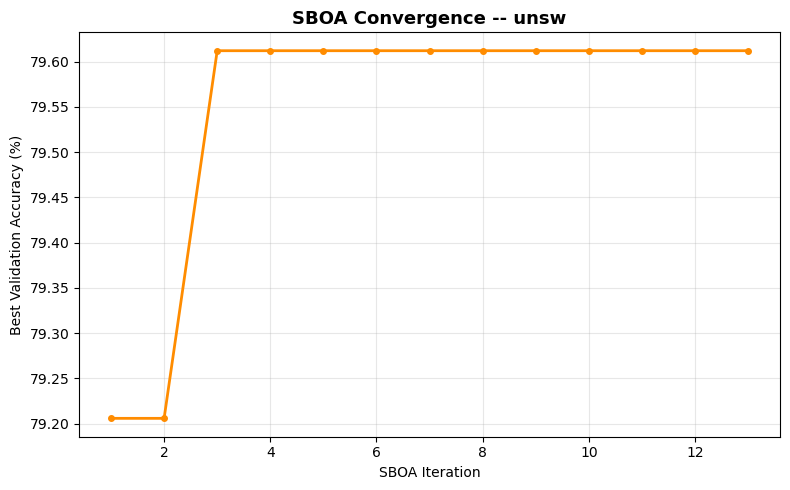

In [14]:
if convergence:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(np.arange(1, len(convergence) + 1), np.array(convergence) * 100,
            marker="o", ms=4, color="darkorange", lw=2)
    ax.set_xlabel("SBOA Iteration"); ax.set_ylabel("Best Validation Accuracy (%)")
    ax.set_title(f"SBOA Convergence -- {DATASET}", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"sboa_convergence_{DATASET}.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No convergence history available (RUN_SBOA=False and no cached history).")


In [15]:
theta_df = pd.DataFrame(
    [{"Hyperparameter": k, "Value": v} for k, v in theta_star.items()]
).set_index("Hyperparameter")
print(f"SBOA-selected hyperparameters ({DATASET}):")
display(theta_df)

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\caption{SBOA-selected hyperparameters for the GCN-BiGRU model (" + DATASET + r")}\label{tab:sboa_theta_" + DATASET + "}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{@{}ll@{}}")
lines.append(r"\toprule")
lines.append(r"Hyperparameter & Value \\")
lines.append(r"\midrule")
for k, v in theta_star.items():
    vs = f"{v:.5g}" if isinstance(v, float) else str(v)
    lines.append(f"{k} & {vs} " + r"\\")
lines.append(r"\botrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
print("\n--- LaTeX ---")
print("\n".join(lines))


SBOA-selected hyperparameters (unsw):


,Value
Hyperparameter,
bigru1,131
bigru2,16
lr,0.001519
dropout,0.199971
optimizer,adam
top_k,12



--- LaTeX ---
\begin{table}[htbp]
\caption{SBOA-selected hyperparameters for the GCN-BiGRU model (unsw)}\label{tab:sboa_theta_unsw}
\centering
\begin{tabular}{@{}ll@{}}
\toprule
Hyperparameter & Value \\
\midrule
bigru1 & 131 \\
bigru2 & 16 \\
lr & 0.0015192 \\
dropout & 0.19997 \\
optimizer & adam \\
top_k & 12 \\
\botrule
\end{tabular}
\end{table}


## 8. Final Model Training at Full Budget
The final model is built with the SBOA-selected hyperparameters `theta_star` and trained at the
full epoch budget (`EPOCHS`) on the full training split (`FINAL_FULL_DATA=True`), or on the same
subsample used for the SBOA search when `FINAL_FULL_DATA=False` (useful for a quick end-to-end
smoke test).

In [16]:
FINAL_TOP_K = theta_star["top_k"]
A_final = adjacency_from_corr(CORR_TRAIN, FINAL_TOP_K)

tf.keras.backend.clear_session()
np.random.seed(SEED)
tf.random.set_seed(SEED)

model = build_gcn_bigru(NUM_FEATURES, NUM_CLASSES, A_final, TIMESTEPS,
                         dropout=theta_star["dropout"], reg=REG,
                         bigru1=theta_star["bigru1"], bigru2=theta_star["bigru2"],
                         top_k=FINAL_TOP_K, adaptive=ADAPTIVE_GRAPH)

opt = OPTIMIZERS[theta_star["optimizer"]](learning_rate=theta_star["lr"], clipnorm=1.0)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "GCN_BiGRU_unsw"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1, 390)]          0         
                                                                 
 adaptive_gcn (AdaptiveGCN)  (None, 1, 390)            304590    
                                                                 
 bidirectional (Bidirectiona  (None, 1, 262)           411078    
 l)                                                              
                                                                 
 batch_normalization (BatchN  (None, 1, 262)           1048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1, 262)            0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 32)            

In [17]:
if FINAL_FULL_DATA or not RUN_SBOA:
    X_fit, y_fit = X_train_lstm, y_train
    X_fit_val, y_fit_val = X_val_lstm, y_val
else:
    X_fit, y_fit = X_sb_tr_lstm, y_sb_tr
    X_fit_val, y_fit_val = X_sb_va_lstm, y_sb_va

AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=False):
    with tf.device("/CPU:0"):
        ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=20_000, seed=SEED)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(X_fit, y_fit, shuffle=True)
val_ds   = make_dataset(X_fit_val, y_fit_val)

ckpt_path = f"best_model_{DATASET}.weights.h5"
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, mode="min", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True,
                    mode="min", save_weights_only=True, verbose=0),
]

t_train0 = time.perf_counter()
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks,
    class_weight=CLASS_WEIGHTS, verbose=1,
)
train_time_sec = time.perf_counter() - t_train0
# restore_best_weights=True -> model already carries the best checkpoint
best_model = model


Epoch 1/100
353/353 [==============================] - 18s 35ms/step - loss: 0.8138 - accuracy: 0.7352 - val_loss: 1.0649 - val_accuracy: 0.7067 - lr: 0.0015
Epoch 2/100
353/353 [==============================] - 11s 32ms/step - loss: 0.3957 - accuracy: 0.7709 - val_loss: 0.5962 - val_accuracy: 0.7801 - lr: 0.0015
Epoch 3/100
353/353 [==============================] - 11s 32ms/step - loss: 0.3583 - accuracy: 0.7785 - val_loss: 0.5717 - val_accuracy: 0.7846 - lr: 0.0015
Epoch 4/100
353/353 [==============================] - 11s 32ms/step - loss: 0.3452 - accuracy: 0.7813 - val_loss: 0.5506 - val_accuracy: 0.7900 - lr: 0.0015
Epoch 5/100
353/353 [==============================] - 11s 32ms/step - loss: 0.3374 - accuracy: 0.7833 - val_loss: 0.5446 - val_accuracy: 0.7871 - lr: 0.0015
Epoch 6/100
353/353 [==============================] - 12s 33ms/step - loss: 0.3317 - accuracy: 0.7844 - val_loss: 0.5397 - val_accuracy: 0.7861 - lr: 0.0015
Epoch 7/100
353/353 [==============================]

## 9. Training History

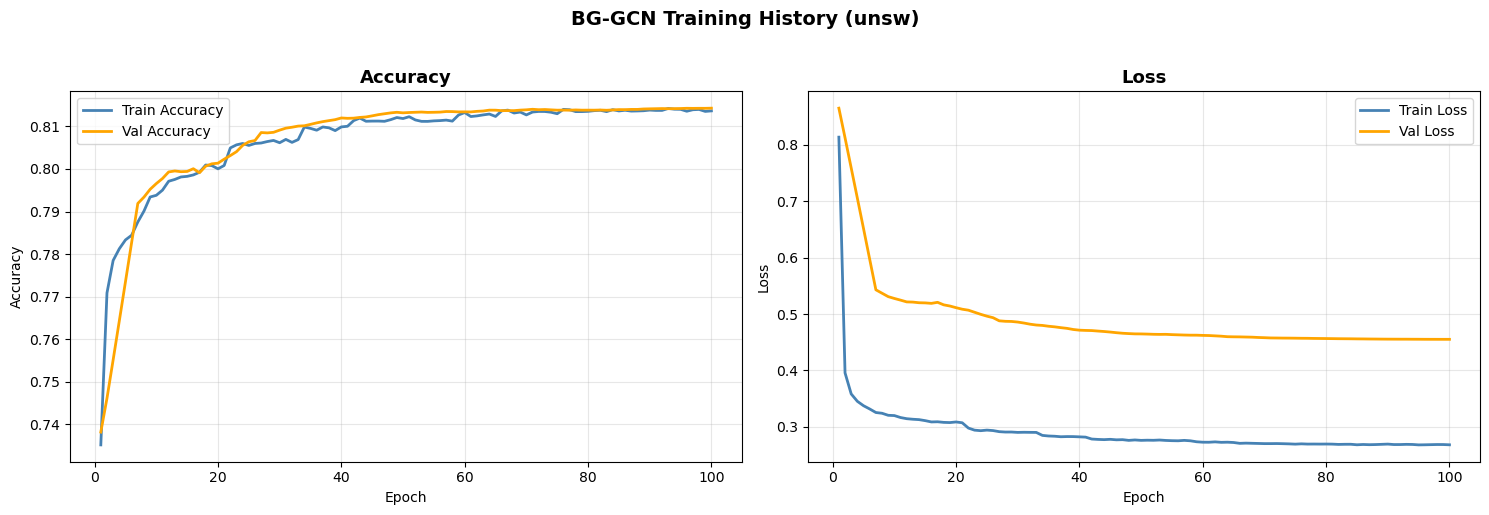

In [18]:
acc      = np.array(history.history.get("accuracy", []), dtype=float)
val_acc  = np.array(history.history.get("val_accuracy", []), dtype=float)
loss     = np.array(history.history.get("loss", []), dtype=float)
val_loss = np.array(history.history.get("val_loss", []), dtype=float)
epochs_range = np.arange(1, len(acc) + 1)

# Smooth validation curves with a moving average; raw curves are noisy epoch-to-epoch.
W = max(3, len(acc) // 10)
def smooth(x):
    return uniform_filter1d(x, size=W, mode="nearest") if len(x) else x

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs_range, acc, color="steelblue", lw=2, label="Train Accuracy")
ax1.plot(epochs_range, smooth(val_acc), color="orange", lw=2, label="Val Accuracy")
ax1.set_title("Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, color="steelblue", lw=2, label="Train Loss")
ax2.plot(epochs_range, smooth(val_loss), color="orange", lw=2, label="Val Loss")
ax2.set_title("Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f"{MODEL_NAME} Training History ({DATASET})", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"training_history_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Performance Table (Train / Val / Test)

In [19]:
def evaluate_split(Xs, ys):
    probs = best_model.predict(Xs, batch_size=BATCH, verbose=0)
    preds = np.argmax(probs, axis=1)
    return (
        accuracy_score(ys, preds) * 100,
        precision_score(ys, preds, average="weighted", zero_division=0) * 100,
        recall_score(ys, preds, average="weighted", zero_division=0) * 100,
        f1_score(ys, preds, average="weighted", zero_division=0) * 100,
        log_loss(ys, probs, labels=np.arange(NUM_CLASSES)),
    )

train_m = evaluate_split(X_train_lstm, y_train)
val_m   = evaluate_split(X_val_lstm, y_val)
test_m  = evaluate_split(X_test_lstm, y_test)
rows_perf = [("Training", train_m), ("Validation", val_m), ("Testing", test_m)]

perf_df = pd.DataFrame([
    {"Dataset Split": split, "Accuracy (%)": round(m[0], 2), "Precision (%)": round(m[1], 2),
     "Recall (%)": round(m[2], 2), "F1-score (%)": round(m[3], 2), "Loss": round(m[4], 4)}
    for split, m in rows_perf
]).set_index("Dataset Split")
print(f"Performance on Training, Validation and Testing datasets ({MODEL_NAME}, {DATASET}):")
display(perf_df)

RESULTS["performance"] = {
    split: {"accuracy": m[0], "precision": m[1], "recall": m[2], "f1": m[3], "loss": m[4]}
    for split, m in rows_perf
}
RESULTS["config"] = {
    "adaptive_graph": ADAPTIVE_GRAPH, "theta_star": theta_star,
    "final_full_data": FINAL_FULL_DATA, "train_time_sec": train_time_sec,
}
save_results()

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\caption{Performance analysis of the proposed BG-GCN model on training, validation, and testing datasets (" + DATASET + r")}\label{tab:performance_" + DATASET + "}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{@{}lccccc@{}}")
lines.append(r"\toprule")
lines.append(r"Dataset Split & Accuracy (\%) & Precision (\%) & Recall (\%) & F1-score (\%) & Loss \\")
lines.append(r"\midrule")
for split, m in rows_perf:
    lines.append(f"{split} & {m[0]:.2f} & {m[1]:.2f} & {m[2]:.2f} & {m[3]:.2f} & {m[4]:.4f} " + r"\\")
lines.append(r"\botrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
print("\n--- LaTeX ---")
print("\n".join(lines))


Performance on Training, Validation and Testing datasets (BG-GCN, unsw):


,Accuracy (%),Precision (%),Recall (%),F1-score (%),Loss
Dataset Split,,,,,
Training,81.72,81.78,81.72,78.79,0.4402
Validation,81.44,81.95,81.44,78.54,0.4483
Testing,81.48,81.75,81.48,78.61,0.4478


Saved results -> results\results_unsw.json

--- LaTeX ---
\begin{table}[htbp]
\caption{Performance analysis of the proposed BG-GCN model on training, validation, and testing datasets (unsw)}\label{tab:performance_unsw}
\centering
\begin{tabular}{@{}lccccc@{}}
\toprule
Dataset Split & Accuracy (\%) & Precision (\%) & Recall (\%) & F1-score (\%) & Loss \\
\midrule
Training & 81.72 & 81.78 & 81.72 & 78.79 & 0.4402 \\
Validation & 81.44 & 81.95 & 81.44 & 78.54 & 0.4483 \\
Testing & 81.48 & 81.75 & 81.48 & 78.61 & 0.4478 \\
\botrule
\end{tabular}
\end{table}


## 11. Confusion Matrix -- True vs Predicted Attack Labels

Test-set classification report:
                precision    recall  f1-score   support

      Analysis       0.21      0.13      0.16       401
      Backdoor       0.39      0.11      0.17       349
           DoS       0.65      0.01      0.03      2453
      Exploits       0.60      0.90      0.72      6679
       Fuzzers       0.74      0.44      0.55      3637
       Generic       1.00      0.97      0.99      8831
        Normal       0.88      0.96      0.92     13950
Reconnaissance       0.91      0.77      0.83      2098
     Shellcode       0.44      0.83      0.57       227
         Worms       0.18      0.65      0.28        26

      accuracy                           0.81     38651
     macro avg       0.60      0.58      0.52     38651
  weighted avg       0.82      0.81      0.79     38651



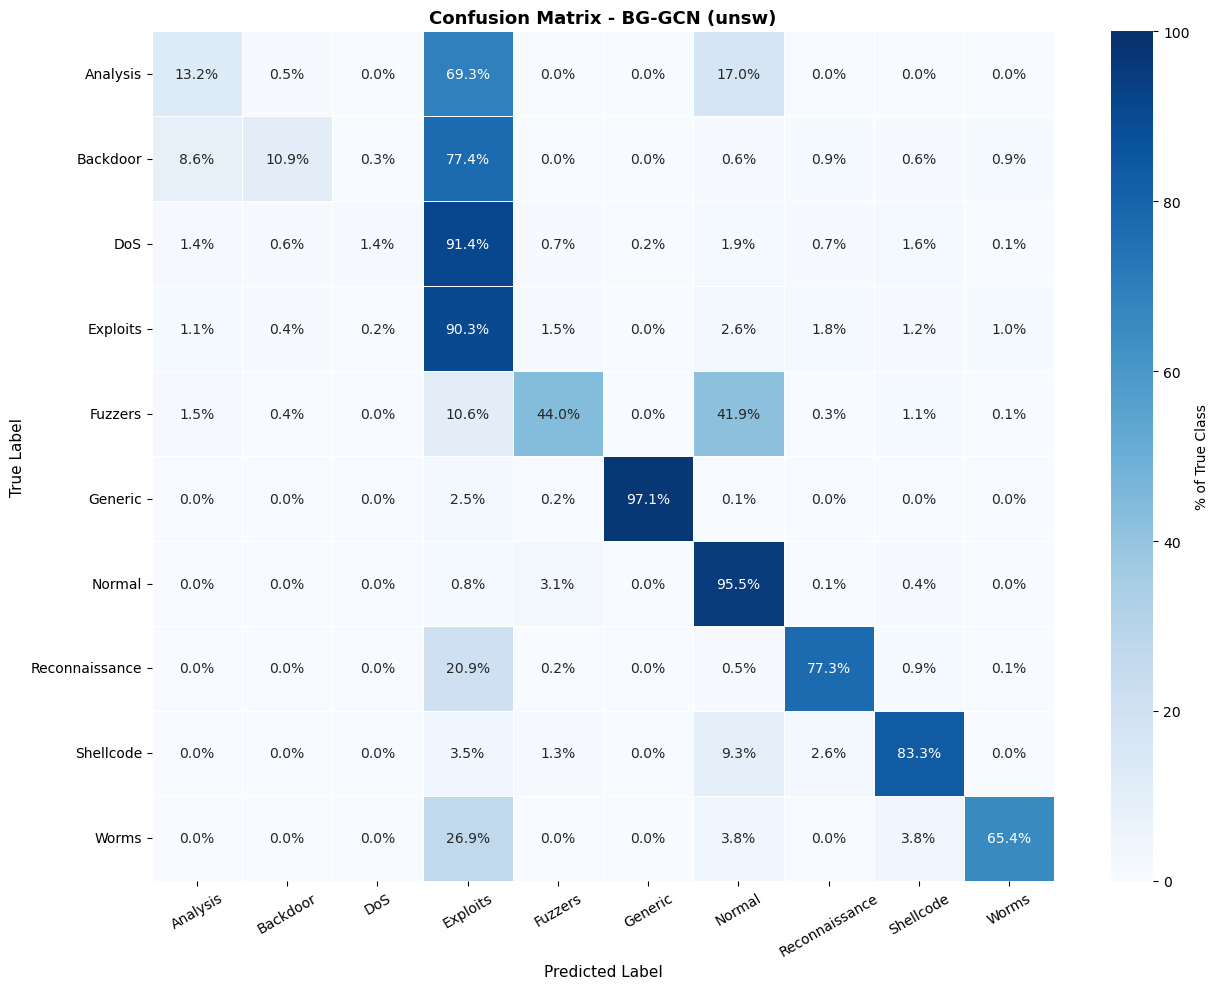

Per-class Detection Rate:


,Total Samples,Correctly Predicted,Detection Rate (%)
True Label,,,
Analysis,401,53,13.22
Backdoor,349,38,10.89
DoS,2453,35,1.43
Exploits,6679,6032,90.31
Fuzzers,3637,1600,43.99
Generic,8831,8578,97.14
Normal,13950,13329,95.55
Reconnaissance,2098,1622,77.31
Shellcode,227,189,83.26


In [20]:
y_prob_test = best_model.predict(X_test_lstm, batch_size=BATCH, verbose=0)
pred        = np.argmax(y_prob_test, axis=1)
y_eval      = y_test

print("Test-set classification report:")
print(classification_report(y_eval, pred, target_names=CLASS_ORDER, zero_division=0))

y_true_lbl = np.array([CLASS_ORDER[i] for i in y_eval])
y_pred_lbl = np.array([CLASS_ORDER[i] for i in pred])
labels = CLASS_ORDER.copy()

cm_counts = confusion_matrix(y_true_lbl, y_pred_lbl, labels=labels)
cm_pct = cm_counts.astype(float) / (cm_counts.sum(axis=1, keepdims=True) + 1e-9) * 100
annot = np.array([[f"{v:.1f}%" for v in row] for row in cm_pct])

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.3), max(7, len(labels) * 1.0)))
sns.heatmap(
    cm_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=100,
    cbar_kws={"label": "% of True Class"},
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor="white", ax=ax,
)
ax.set_title(f"Confusion Matrix - {MODEL_NAME} ({DATASET})", fontsize=13, fontweight="bold")
ax.set_ylabel("True Label", fontsize=11)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(f"confusion_matrix_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()

det = pd.DataFrame({
    "True Label": labels,
    "Total Samples": cm_counts.sum(axis=1),
    "Correctly Predicted": cm_counts.diagonal(),
    "Detection Rate (%)": cm_pct.diagonal().round(2),
}).set_index("True Label")
print("Per-class Detection Rate:")
display(det)


## 12. Class-wise Additional Performance Indicators
FPR, FNR, FDR, FOR, TNR, MCC, and NPV per attack class.

In [21]:
rows = []
for i, label in enumerate(labels):
    y_tb = (np.array(y_true_lbl) == label).astype(int)
    y_pb = (np.array(y_pred_lbl) == label).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_tb, y_pb, labels=[0, 1]).ravel()

    fpr = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0.0
    fdr = fp / (fp + tp) * 100 if (fp + tp) > 0 else 0.0
    for_ = fn / (fn + tn) * 100 if (fn + tn) > 0 else 0.0
    tnr = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0.0
    npv = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0.0
    mcc = matthews_corrcoef(y_tb, y_pb) if len(np.unique(y_tb)) > 1 and len(np.unique(y_pb)) > 1 else 0.0

    rows.append({
        "Class": f"Class {i} ({label})",
        "FPR (%)": round(fpr, 4), "FNR (%)": round(fnr, 4),
        "FDR (%)": round(fdr, 4), "FOR (%)": round(for_, 4),
        "TNR (%)": round(tnr, 4), "MCC": round(mcc, 4), "NPV (%)": round(npv, 4),
    })

df_adv = pd.DataFrame(rows).set_index("Class")
print(f"Class-wise Additional Performance Indicators ({MODEL_NAME}):")
display(df_adv)

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\caption{Class-wise additional performance indicators of the proposed BG-GCN model (" + DATASET + r")}\label{tab:classwise_" + DATASET + "}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{@{}lcccc@{}}")
lines.append(r"\toprule")
lines.append(r"Class & FPR (\%) & FNR (\%) & FDR (\%) & FOR (\%) \\")
lines.append(r"\midrule")
for r in rows:
    lines.append(
        f"{r['Class']} & {r['FPR (%)']:.4f} & {r['FNR (%)']:.4f} & {r['FDR (%)']:.4f} & "
        f"{r['FOR (%)']:.4f} " + r"\\"
    )
lines.append(r"\botrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
print("\n--- LaTeX ---")
print("\n".join(lines))


Class-wise Additional Performance Indicators (BG-GCN):


,FPR (%),FNR (%),FDR (%),FOR (%),TNR (%),MCC,NPV (%)
Class,,,,,,,
Class 0 (Analysis),0.5098,86.7830,78.6290,0.9062,99.4902,0.1613,99.0938
Class 1 (Backdoor),0.1566,89.1117,61.2245,0.8067,99.8434,0.2019,99.1933
Class 2 (DoS),0.0525,98.5732,35.1852,6.2647,99.9475,0.0897,93.7353
Class 3 (Exploits),12.3827,9.6871,39.6257,2.2575,87.6173,0.6730,97.7425
Class 4 (Fuzzers),1.6336,56.0077,26.3352,5.5840,98.3664,0.5370,94.4160
Class 5 (Generic),0.0235,2.8649,0.0815,0.8415,99.9765,0.9809,99.1585
Class 6 (Normal),7.5098,4.4516,12.2168,2.6463,92.4902,0.8658,97.3537
Class 7 (Reconnaissance),0.4569,22.6883,9.3348,1.2913,99.5431,0.8288,98.7087
Class 8 (Shellcode),0.6376,16.7401,56.4516,0.0994,99.3624,0.5992,99.9006



--- LaTeX ---
\begin{table}[htbp]
\caption{Class-wise additional performance indicators of the proposed BG-GCN model (unsw)}\label{tab:classwise_unsw}
\centering
\begin{tabular}{@{}lcccc@{}}
\toprule
Class & FPR (\%) & FNR (\%) & FDR (\%) & FOR (\%) \\
\midrule
Class 0 (Analysis) & 0.5098 & 86.7830 & 78.6290 & 0.9062 \\
Class 1 (Backdoor) & 0.1566 & 89.1117 & 61.2245 & 0.8067 \\
Class 2 (DoS) & 0.0525 & 98.5732 & 35.1852 & 6.2647 \\
Class 3 (Exploits) & 12.3827 & 9.6871 & 39.6257 & 2.2575 \\
Class 4 (Fuzzers) & 1.6336 & 56.0077 & 26.3352 & 5.5840 \\
Class 5 (Generic) & 0.0235 & 2.8649 & 0.0815 & 0.8415 \\
Class 6 (Normal) & 7.5098 & 4.4516 & 12.2168 & 2.6463 \\
Class 7 (Reconnaissance) & 0.4569 & 22.6883 & 9.3348 & 1.2913 \\
Class 8 (Shellcode) & 0.6376 & 16.7401 & 56.4516 & 0.0994 \\
Class 9 (Worms) & 0.2045 & 34.6154 & 82.2917 & 0.0233 \\
\botrule
\end{tabular}
\end{table}


## 13. Bar Chart: TNR, MCC, and NPV per Attack Class

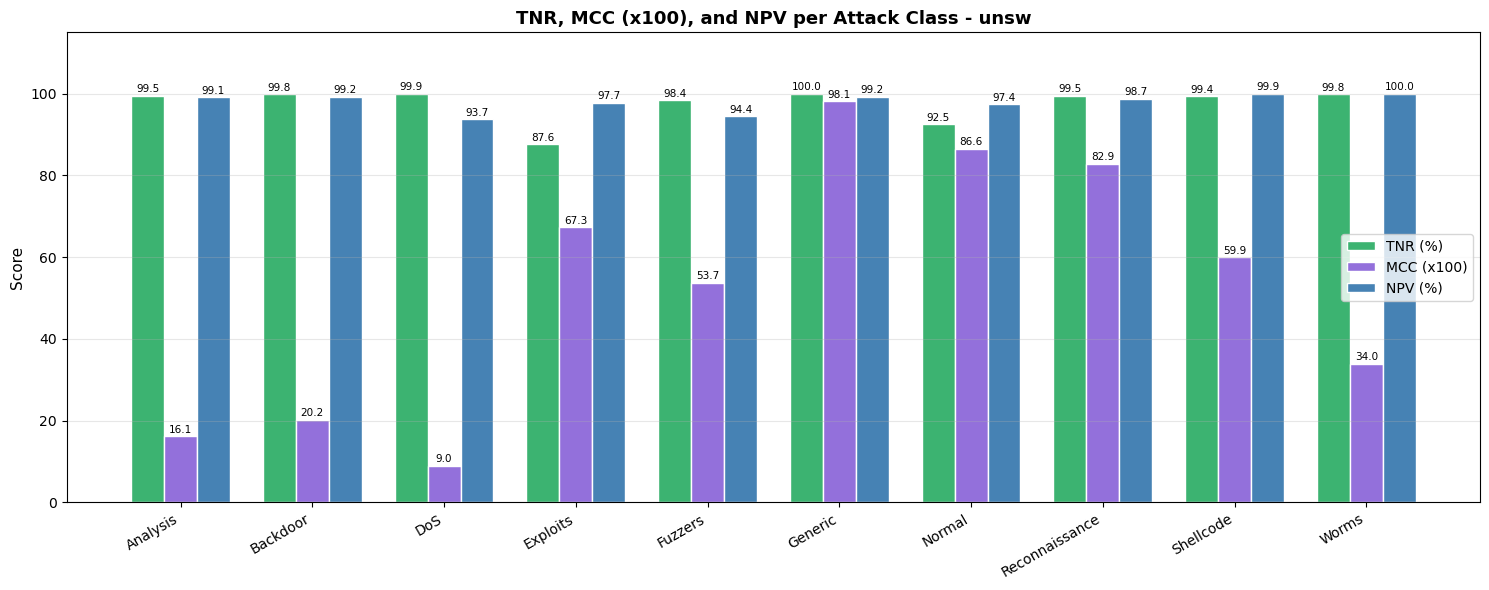

In [22]:
class_labels = [l.split("(")[1].rstrip(")") for l in df_adv.index]
tnr_vals = df_adv["TNR (%)"].values
mcc_vals = df_adv["MCC"].values * 100
npv_vals = df_adv["NPV (%)"].values

x = np.arange(len(class_labels))
w = 0.25

fig, ax = plt.subplots(figsize=(max(14, len(class_labels) * 1.5), 6))
b1 = ax.bar(x - w, tnr_vals, w, label="TNR (%)", color="mediumseagreen", edgecolor="white")
b2 = ax.bar(x, mcc_vals, w, label="MCC (x100)", color="mediumpurple", edgecolor="white")
b3 = ax.bar(x + w, npv_vals, w, label="NPV (%)", color="steelblue", edgecolor="white")

for bars, vals in [(b1, tnr_vals), (b2, mcc_vals), (b3, npv_vals)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f"{val:.1f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title(f"TNR, MCC (x100), and NPV per Attack Class - {DATASET}", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"tnr_mcc_npv_barchart_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. ROC Curve (One-vs-Rest, per Attack Class)

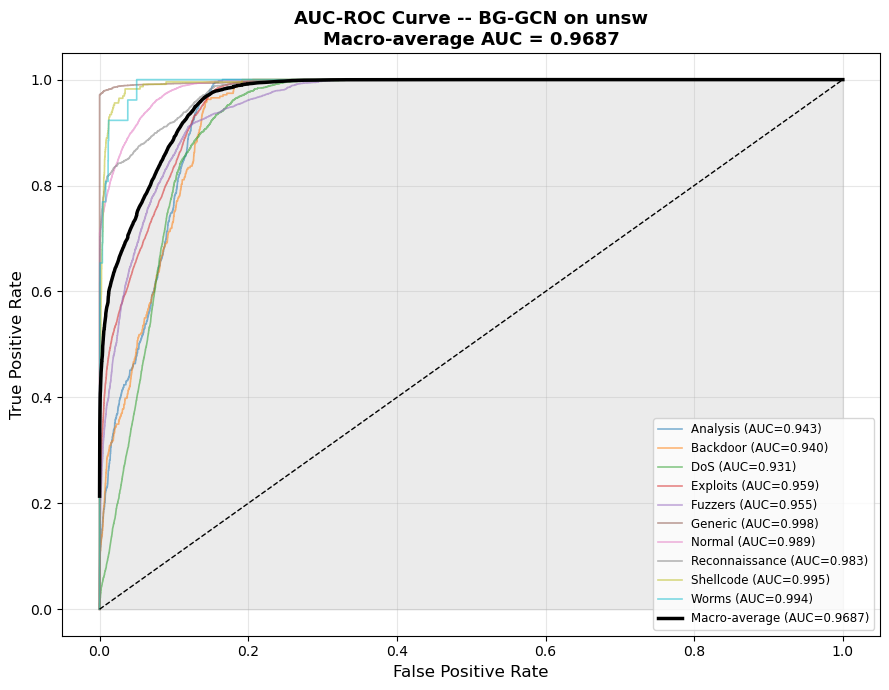

Macro-average AUC: 0.9687
Saved results -> results\results_unsw.json


In [23]:
y_test_ovr = label_binarize(y_eval, classes=np.arange(NUM_CLASSES))
y_prob_roc = best_model.predict(X_test_lstm, batch_size=BATCH, verbose=0)

fpr_all, tpr_all = {}, {}
for i in range(NUM_CLASSES):
    fpr_all[i], tpr_all[i], _ = roc_curve(y_test_ovr[:, i], y_prob_roc[:, i])

all_fpr = np.unique(np.concatenate([fpr_all[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

palette = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
fig, ax = plt.subplots(figsize=(9, 7))

for i, color in enumerate(palette):
    auc_i = auc(fpr_all[i], tpr_all[i])
    ax.plot(fpr_all[i], tpr_all[i], color=color, lw=1.2, alpha=0.55,
            label=f"{CLASS_ORDER[i]} (AUC={auc_i:.3f})")

ax.plot(all_fpr, mean_tpr, color="black", lw=2.5, label=f"Macro-average (AUC={macro_auc:.4f})")
ax.fill_between(all_fpr, mean_tpr, alpha=0.08, color="black")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"AUC-ROC Curve -- {MODEL_NAME} on {DATASET}\nMacro-average AUC = {macro_auc:.4f}",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=8.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"auc_roc_curve_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Macro-average AUC: {macro_auc:.4f}")

RESULTS.setdefault("performance", {})["macro_auc"] = float(macro_auc)
save_results()


## 15. Computational Time Analysis

In [24]:
def measure_time(X_data):
    best_model.predict(X_data[:64], batch_size=BATCH, verbose=0)  # warm-up
    t0 = time.perf_counter()
    best_model.predict(X_data, batch_size=BATCH, verbose=0)
    return time.perf_counter() - t0

tr_sec  = measure_time(X_train_lstm)
val_sec = measure_time(X_val_lstm)
te_sec  = measure_time(X_test_lstm)
total_sec = tr_sec + val_sec + te_sec

cost_rows = [
    {"Phase": "Training",   "Time (s)": round(tr_sec, 2),  "Relative Cost (%)": round(tr_sec / total_sec * 100, 1)},
    {"Phase": "Validation", "Time (s)": round(val_sec, 2), "Relative Cost (%)": round(val_sec / total_sec * 100, 1)},
    {"Phase": "Testing",    "Time (s)": round(te_sec, 2),  "Relative Cost (%)": round(te_sec / total_sec * 100, 1)},
]

df_cost = pd.DataFrame(cost_rows).set_index("Phase")
print("Computational Time Analysis (Actual data, inference only):")
display(df_cost)
if RUN_SBOA:
    print(f"SBOA search time: {sboa_time:.1f}s | Final-model training time: {train_time_sec:.1f}s")

RESULTS["timing"] = {
    "inference": {r["Phase"]: r["Time (s)"] for r in cost_rows},
    "train_time_sec": train_time_sec,
    "sboa_search_time_sec": sboa_time if RUN_SBOA else RESULTS.get("sboa", {}).get("search_time_sec"),
}
save_results()

lines = []
lines.append(r"\begin{table}[htbp]")
lines.append(r"\caption{Computational time analysis for training, validation, and testing phases (" + DATASET + r")}\label{tab:t12_" + DATASET + "}")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{@{}lcc@{}}")
lines.append(r"\toprule")
lines.append(r"Phase & Time (s) & Relative Cost (\%) \\")
lines.append(r"\midrule")
for r in cost_rows:
    lines.append(f"{r['Phase']} & {r['Time (s)']:.2f} & {r['Relative Cost (%)']:.1f} " + r"\\")
lines.append(r"\botrule")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")
print("\n--- LaTeX ---")
print("\n".join(lines))


Computational Time Analysis (Actual data, inference only):


,Time (s),Relative Cost (%)
Phase,,
Training,2.51,68.9
Validation,0.57,15.7
Testing,0.56,15.4


SBOA search time: 6860.7s | Final-model training time: 1147.0s
Saved results -> results\results_unsw.json

--- LaTeX ---
\begin{table}[htbp]
\caption{Computational time analysis for training, validation, and testing phases (unsw)}\label{tab:t12_unsw}
\centering
\begin{tabular}{@{}lcc@{}}
\toprule
Phase & Time (s) & Relative Cost (\%) \\
\midrule
Training & 2.51 & 68.9 \\
Validation & 0.57 & 15.7 \\
Testing & 0.56 & 15.4 \\
\botrule
\end{tabular}
\end{table}


## 16. Batch Runner -- Evaluate Several Datasets in One Pass

Set `DATASETS_TO_RUN` (config cell) to the datasets you want to evaluate together, then run the
two cells below. Every dataset is processed in a **fully independent pass** (its own load ->
preprocess -> feature graph -> SBOA -> final training -> evaluation), so runs never share state.

For each dataset:
* if `results/results_<dataset>.json` already holds SBOA-selected hyperparameters, the SBOA
  search is **skipped** and those parameters are reused;
* otherwise, if `RUN_SBOA=True` a fresh SBOA search runs and is cached; if `RUN_SBOA=False`
  the per-dataset default hyperparameters are used.

Outputs per dataset: a performance table, a confusion matrix (`confusion_matrix_<dataset>.png`),
and `results/results_<dataset>.json`. A summary table over all datasets is printed at the end.

In [ ]:
def run_pipeline(dataset, run_sboa=None, max_samples="config", make_plots=True):
    """Fully self-contained, independent evaluation of one dataset.
    Reuses the shared helpers defined above (LOADERS, compute_corr_matrix, adjacency_from_corr,
    build_gcn_bigru, sboa_fitness, run_sboa) but keeps all per-dataset state local, so several
    datasets can be evaluated back-to-back without one run affecting another."""
    import time as _time
    assert dataset in DATASETS_ALL, f"Unknown dataset: {dataset}"
    if run_sboa is None:
        run_sboa = RUN_SBOA
    if max_samples == "config":
        max_samples = MAX_SAMPLES.get(dataset) if isinstance(MAX_SAMPLES, dict) else MAX_SAMPLES
    print("\n" + "=" * 72 + f"\n RUN_PIPELINE :: {dataset}\n" + "=" * 72)
    t_pipe = _time.perf_counter()

    # 1. Load (+ optional stratified cap) --------------------------------------------------
    X_raw, y_all, class_order, _ = LOADERS[dataset]()
    num_classes = len(class_order)
    print(f"[{dataset}] raw features={X_raw.shape[1]} samples={X_raw.shape[0]:,} classes={num_classes}")
    if max_samples and len(X_raw) > max_samples:
        X_raw, _, y_all, _ = train_test_split(X_raw, y_all, train_size=max_samples,
                                              random_state=SEED, stratify=y_all)
        print(f"[{dataset}] stratified cap -> {max_samples:,} rows")

    # 2. Split 70/15/15 (stratified) -------------------------------------------------------
    X_tmp, X_test, y_tmp, y_test = train_test_split(X_raw, y_all, test_size=TEST_FRAC,
                                                    random_state=SEED, stratify=y_all)
    X_tr, X_val, y_tr, y_val = train_test_split(X_tmp, y_tmp, test_size=VAL_FRAC,
                                                random_state=SEED, stratify=y_tmp)

    # 3. Preprocess (fit on train only) ----------------------------------------------------
    imp = SimpleImputer(strategy="median")
    X_tr = imp.fit_transform(X_tr); X_val = imp.transform(X_val); X_test = imp.transform(X_test)
    def _addlog(X): return np.hstack([X, np.log1p(np.clip(X, 0, None))])
    X_tr, X_val, X_test = _addlog(X_tr), _addlog(X_val), _addlog(X_test)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr); X_val = scaler.transform(X_val); X_test = scaler.transform(X_test)
    vt = VarianceThreshold(1e-4)
    X_tr = vt.fit_transform(X_tr); X_val = vt.transform(X_val); X_test = vt.transform(X_test)
    nf = X_tr.shape[1]
    _rs = lambda A: A.reshape(-1, TIMESTEPS, nf)
    X_tr_l, X_val_l, X_test_l = _rs(X_tr), _rs(X_val), _rs(X_test)
    print(f"[{dataset}] features(after log1p+varfilter)={nf} | "
          f"train={len(X_tr):,} val={len(X_val):,} test={len(X_test):,}")

    corr_train = compute_corr_matrix(X_tr)
    freq = np.bincount(y_tr, minlength=num_classes).astype(float) / len(y_tr)
    cw = 1.0 / np.sqrt(freq + 1e-8); cw = np.clip(cw / cw.mean(), 0.5, 15.0)
    class_weights = dict(enumerate(cw))

    # 4. SBOA -- skip if cached, else search (or default) ----------------------------------
    res = load_results(dataset)
    cached_theta = res.get("sboa", {}).get("theta_star")
    convergence = res.get("sboa", {}).get("convergence", [])
    if cached_theta:
        theta_star = cached_theta
        print(f"[{dataset}] cached SBOA hyperparameters found -> skipping search. theta*={theta_star}")
    elif run_sboa:
        print(f"[{dataset}] no cached SBOA params -> running SBOA (P={SBOA_POP}, T={SBOA_ITERS})")
        n_sub = min(max(int(len(X_tr) * SBOA_SAMPLE_FRAC), BATCH * 4), len(X_tr))
        si = np.random.default_rng(SEED).choice(len(X_tr), size=n_sub, replace=False)
        Xs, ys = X_tr[si], y_tr[si]
        Xstr, Xsva, ystr, ysva = train_test_split(Xs, ys, test_size=0.2, random_state=SEED, stratify=ys)
        corr_sboa = compute_corr_matrix(Xstr)
        Xstr_l = Xstr.reshape(-1, TIMESTEPS, nf); Xsva_l = Xsva.reshape(-1, TIMESTEPS, nf)
        def _fit(v):
            return sboa_fitness(v, Xstr_l, ystr, Xsva_l, ysva, corr_sboa, num_classes, nf, TIMESTEPS)
        _t0 = _time.perf_counter()
        _, theta_star, best_f, convergence = run_sboa(_fit, dim=DIM, pop_size=SBOA_POP,
                                                      iters=SBOA_ITERS, seed=SEED)
        res["sboa"] = {"theta_star": theta_star, "best_val_accuracy": best_f, "convergence": convergence,
                       "search_time_sec": _time.perf_counter() - _t0, "pop_size": SBOA_POP,
                       "iters": SBOA_ITERS, "sample_frac": SBOA_SAMPLE_FRAC, "epochs_per_candidate": SBOA_EPOCHS}
        print(f"[{dataset}] SBOA done (val_acc={best_f*100:.2f}%). theta*={theta_star}")
    else:
        theta_star = DEFAULT_THETA_BY_DATASET.get(dataset, DEFAULT_THETA_BY_DATASET["unsw"])
        print(f"[{dataset}] RUN_SBOA=False and no cache -> using default theta*={theta_star}")

    # 5. Final model training at the full budget -------------------------------------------
    A_final = adjacency_from_corr(corr_train, theta_star["top_k"])
    tf.keras.backend.clear_session(); np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_gcn_bigru(nf, num_classes, A_final, TIMESTEPS, dropout=theta_star["dropout"], reg=REG,
                            bigru1=theta_star["bigru1"], bigru2=theta_star["bigru2"],
                            top_k=theta_star["top_k"], adaptive=ADAPTIVE_GRAPH)
    opt = OPTIMIZERS[theta_star["optimizer"]](learning_rate=theta_star["lr"], clipnorm=1.0)
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cbs = [EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, mode="min", verbose=1),
           ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1)]
    _t0 = _time.perf_counter()
    history = model.fit(X_tr_l, y_tr, validation_data=(X_val_l, y_val), epochs=EPOCHS, batch_size=BATCH,
                        class_weight=class_weights, callbacks=cbs, verbose=2)
    train_time = _time.perf_counter() - _t0

    # 6. Evaluate ---------------------------------------------------------------------------
    def _ev(Xs, ys):
        p = model.predict(Xs, batch_size=BATCH, verbose=0); pr = np.argmax(p, 1)
        return (accuracy_score(ys, pr) * 100, precision_score(ys, pr, average="weighted", zero_division=0) * 100,
                recall_score(ys, pr, average="weighted", zero_division=0) * 100,
                f1_score(ys, pr, average="weighted", zero_division=0) * 100,
                log_loss(ys, p, labels=np.arange(num_classes)))
    perf = {"Training": _ev(X_tr_l, y_tr), "Validation": _ev(X_val_l, y_val), "Testing": _ev(X_test_l, y_test)}
    perf_df = pd.DataFrame([{"Dataset Split": k, "Accuracy (%)": round(v[0], 2), "Precision (%)": round(v[1], 2),
                             "Recall (%)": round(v[2], 2), "F1-score (%)": round(v[3], 2), "Loss": round(v[4], 4)}
                            for k, v in perf.items()]).set_index("Dataset Split")
    print(f"[{dataset}] Performance ({MODEL_NAME}):")
    try:
        display(perf_df)
    except NameError:
        print(perf_df)

    res["performance"] = {k: {"accuracy": v[0], "precision": v[1], "recall": v[2], "f1": v[3], "loss": v[4]}
                          for k, v in perf.items()}
    res["config"] = {"adaptive_graph": ADAPTIVE_GRAPH, "theta_star": theta_star, "num_classes": num_classes,
                     "num_features": nf, "class_order": class_order, "train_time_sec": train_time,
                     "max_samples": max_samples}

    # 7. Confusion matrix -------------------------------------------------------------------
    if make_plots:
        y_pred = np.argmax(model.predict(X_test_l, batch_size=BATCH, verbose=0), 1)
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes)).astype(float)
        cm_pct = cm / (cm.sum(1, keepdims=True) + 1e-9) * 100
        fig, ax = plt.subplots(figsize=(max(8, num_classes * 1.1), max(6, num_classes * 0.9)))
        sns.heatmap(cm_pct, annot=np.array([[f"{v:.1f}" for v in r] for r in cm_pct]), fmt="", cmap="Blues",
                    vmin=0, vmax=100, xticklabels=class_order, yticklabels=class_order, ax=ax,
                    cbar_kws={"label": "% of True Class"}, linewidths=0.5, linecolor="white")
        ax.set_title(f"Confusion Matrix - {MODEL_NAME} ({dataset})", fontweight="bold")
        ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label"); ax.tick_params(axis="x", rotation=30)
        plt.tight_layout(); plt.savefig(f"confusion_matrix_{dataset}.png", dpi=150, bbox_inches="tight"); plt.show()

    with open(_results_path(dataset), "w") as f:
        _json.dump(res, f, indent=2, default=float)
    print(f"[{dataset}] saved -> {_results_path(dataset)} | pipeline time {_time.perf_counter() - t_pipe:.0f}s")
    return perf, theta_star

In [ ]:
# Run every dataset in DATASETS_TO_RUN, one fully independent pass each.
_batch_summary = {}
for _ds in DATASETS_TO_RUN:
    try:
        _perf, _theta = run_pipeline(_ds)
        _batch_summary[_ds] = _perf["Testing"]
    except Exception as _e:
        import traceback; traceback.print_exc()
        _batch_summary[_ds] = f"ERROR: {_e}"

print("\n" + "=" * 72 + "\n BATCH SUMMARY (test split)\n" + "=" * 72)
print(f"{'dataset':12s} {'acc':>8} {'prec':>8} {'rec':>8} {'f1':>8}")
for _ds, _v in _batch_summary.items():
    if isinstance(_v, tuple):
        print(f"{_ds:12s} {_v[0]:8.2f} {_v[1]:8.2f} {_v[2]:8.2f} {_v[3]:8.2f}")
    else:
        print(f"{_ds:12s} {_v}")